In [1]:
import h5py
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

from spikeparam.patch.sim import sim_ppoly_dist, sim_patch

from spikeparam.patch.fit import PolySpikeGroup

### PolySpikeGroup

`PolySpikeGroup` is a subclass of `SpikeGroup` that additionally computes a polynomial spline. The two API differences are that the former is initalized with an `degree` argument that determines the order per polynomial, and the `knots` argument may optionally be used to define which points to compute polynomials between, defaulting to: 

```
['ramp_start', 'inflection', 'rise', 'peak', 'decay', 'tau', 'mtau', 'exp_end']
```

Polynomial coefficients are stored in `.df_poly` and `.poly_*` attributes, including:

`.poly_coeffs`
`.poly_fit`
`.poly_knots`
`.poly_degree`
`.poly_r_squared`

In [2]:
# Load data
fs = 200000 

def reader(ind, alt=False):
    
    file = h5py.File('../../pvc-6/153098.04.02_data.h5', 'r')
    dset = file['Sweep_' + str(ind)]
    
    if alt:
        sig = dset[:, 0]
    else:
        sig = dset[:, 1]
    
    return sig

In [3]:
# Fit
degree = [2, 2, 2, 2, 2, 2, 2]
psg = PolySpikeGroup(degree, pad=10, sigma=.05, window_length=(4, 4))

psg.fit(np.arange(20), fs, reader=reader, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/99 [00:00<?, ?it/s]

PolySpike:   0%|          | 0/99 [00:00<?, ?it/s]

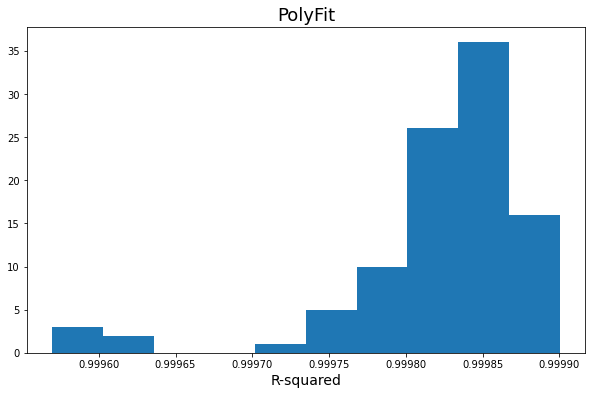

In [4]:
plt.figure(figsize=(10, 6))

plt.hist(psg.poly_r_squared)
plt.title('PolyFit', size=18)
plt.xlabel('R-squared', size=14);

### Simulation

Next, the polynomial and point indices distributions are learned and used to randomly sample a multivariate normal distribution. The sampled parameters are then used to simulate spikes with similar statistics and shapes as the real data.

For any dataset, the mean and covaraiance matrix is all that is need to simulate spikes with similar statistics. We then embed the simulate spikes into a spike train.

In [5]:
# Simulate
n_sims = 100

psg.simulate(n_sims, seeds=np.arange(n_sims), cov_weight=.5)

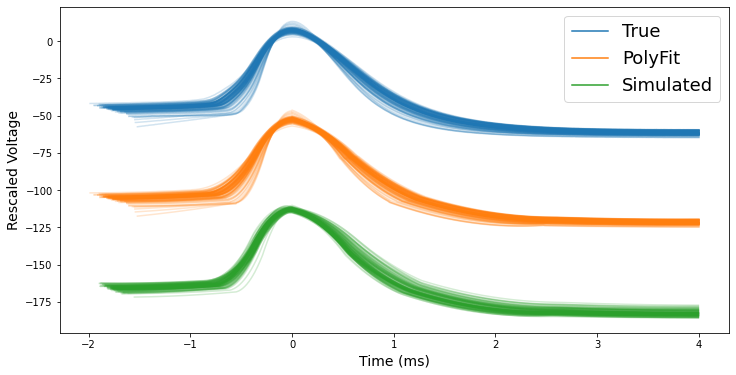

In [6]:
# Plot true and fitted spikes
plt.figure(figsize=(12, 6))
for ind in range(len(psg.spikes)):
    
    inds = np.where(np.isnan(psg.poly_fit[ind]))
    
    ys = psg.spikes[ind].copy()
    ys[inds] = np.nan
      
    l0 = 'True' if ind == 0 else ''
    l1 = 'PolyFit' if ind == 0 else ''
        
    plt.plot(psg.times * 1000, ys, color='C0', alpha=.2, label=l0)
    
    ys = psg.poly_fit[ind]
    plt.plot(psg.times * 1000, ys-60, color='C1', alpha=.2, label=l1)
    
# Plot simulated spikes
min_samples = np.min(psg.sim_knots[:, 0] - psg.sim_knots[:, 3])

max_samples = np.max(psg.sim_knots[:, -1] - psg.sim_knots[:, 3])

times_sim = np.arange(min_samples, max_samples) / psg.fs

for ind in range(len(psg.sim_spikes)):

    l2 = 'Simulated'  if ind == 0 else ''
        
    plt.plot(times_sim * 1000, psg.sim_spikes[ind]-120, color='C2', alpha=.2, label=l2)
    
# Add legend
leg = plt.legend(fontsize=18)

for lh in leg.legendHandles: 
    lh.set_alpha(1)
    
plt.ylabel('Rescaled Voltage', size=14)
plt.xlabel('Time (ms)', size=14);

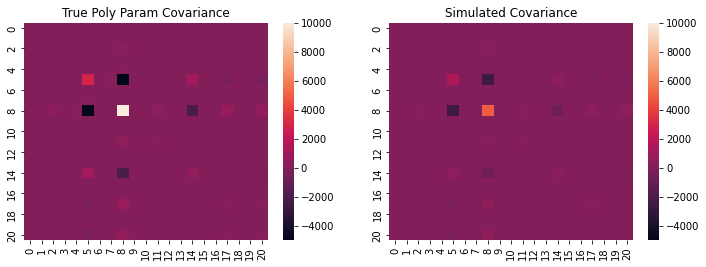

In [7]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 4))

sns.heatmap(np.cov(psg.poly_coeffs, rowvar=0), ax=axes[0], vmin=-5000, vmax=10000)
sns.heatmap(np.cov(psg.sim_coeffs, rowvar=0), ax=axes[1], vmin=-5000, vmax=10000)

axes[0].set_title('True Poly Param Covariance')
axes[1].set_title('Simulated Covariance');

### Spike Trains

Simulated spikes may also be embedded in a continuous time series using the `sim_patch` function.

In [8]:
spikes, _, _ = sim_ppoly_dist(psg.sim_means, psg.sim_cov, psg.degree, 50, seeds=np.arange(50))

isi = np.random.exponential(scale=(fs / 1000) * 10, size=len(spikes)-1).astype(int)

isi += 50 # min refactory period

sig = sim_patch(spikes, isi, 100)

times = np.arange(0, len(sig)/fs, 1/fs)

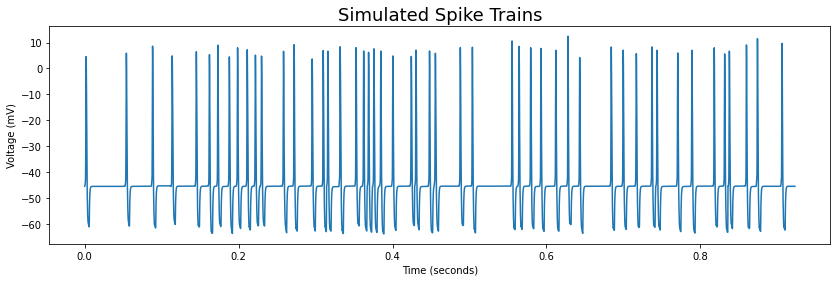

In [9]:
plt.figure(figsize=(14, 4))

plt.plot(times, sig)

plt.title('Simulated Spike Trains', size=18)
plt.ylabel('Voltage (mV)')
plt.xlabel('Time (seconds)');